# GRUPO 4: Camila Contreras, Christian Pérez, Javier Uribe.  
# Proyecto: Análisis de Mamografías y Predicción de Cáncer de Mama


## 1. Introducción
El cáncer de mama es una de las principales causas de muerte entre mujeres en todo el mundo. La detección temprana y el diagnóstico preciso son cruciales para mejorar las tasas de supervivencia.
Este proyecto se centra en el análisis de mamografías para identificar patrones que puedan ayudar a distinguir entre tumores benignos y malignos. Utilizaremos técnicas de análisis estadístico, modelos predictivos y reducción de dimensionalidad para lograr este objetivo.


## 2. Objetivo
Analizar parámetros derivados de mamografías para distinguir entre tumores benignos y malignos.

### Metodología

1. **Análisis Exploratorio de Datos (EDA)**: Visualización y análisis de la distribución de características, correlaciones y patrones en los datos.
2. **Preprocesamiento de Datos**: Limpieza y transformación de los datos para prepararlos para el modelado, incluyendo la normalización y la reducción de dimensionalidad.
3. **Modelado Predictivo**: Implementación de modelos de machine learning para clasificar tumores como benignos o malignos.
4. **Evaluación de Modelos**: Uso de métricas de rendimiento para evaluar la efectividad de los modelos y realizar ajustes según sea necesario.


## 3. Dataset y Carga

El dataset puede ser descargado mediante la siguiente celda de código:

In [1]:
!wget https://raw.githubusercontent.com/iHealthInstitute/Talleres_Diplomado_iHealth/refs/heads/main/data/Mamography_data.csv

--2026-01-16 14:08:41--  https://raw.githubusercontent.com/iHealthInstitute/Talleres_Diplomado_iHealth/refs/heads/main/data/Mamography_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 127043 (124K) [text/plain]
Saving to: ‘Mamography_data.csv’

Mamography_data.csv 100%[===================>] 124.07K  --.-KB/s    in 0.07s   

2026-01-16 14:08:41 (1.79 MB/s) - ‘Mamography_data.csv’ saved [127043/127043]



## 4. Enunciado

Se busca predecir si un tumor es benigno o maligno a partir de los parámetros derivados de mamografías. El dataset contiene varias características numéricas que describen las propiedades de los tumores, así como una etiqueta que indica si el tumor es benigno o maligno.

En particular, hay 6 variables de interés y una variable objetivo:
- `label`: Variable objetivo (Benign o Malignant).
- Variables predictoras a analizar:
  - `mean texture`
  - `mean radius`
  - `mean fractal dimension`
  - `mean smoothness`
  - `mean compactness`
  - `mean concavity`

---
### Parte 1: Análisis Exploratorio y Estadística Inferencial

1. Carga el dataset y revisa sus dimensiones y tipos de variables. Asegurate de solo trabajar con las 6 variables mencionadas y la variable `diagnosis`.
2. Genera un `pairplot` (o matriz de gráficos) de las variables seleccionadas usando la librería `seaborn`. Usa `diagnosis` como variable de color (`hue`).
3. Verifica la distribución de cada una de las 6 variables por separado (en cada grupo):
   - Aplica el test de normalidad de Shapiro-Wilk por separado en los grupos Benigno y Maligno.
   - ¿Distribuyen normalmente? ¿En qué grupo? ¿En qué variables?
4. Aplica pruebas estadísticas para comparar los grupos:
   - Si se cumple normalidad: Aplica un t-test independiente.
   - Si **no** se cumple normalidad: Aplica una prueba de Mann-Whitney U.
5. Para cada variable, responde:
   - ¿Cuál grupo tiene mayor valor promedio?
   - ¿Es significativa la diferencia?




In [2]:
# <CODE> Librerías
import pandas as pd
import os
from matplotlib import pyplot as plt
import kagglehub

In [3]:
# Cargar el dataset
df = pd.read_csv('Mamography_data.csv')

# Visualizar las primeras filas
print("--- Primeras 5 filas ---")
print(df.head())

# Información general de las columnas y tipos de datos
print("\n--- Información del Dataset ---")
print(df.info())

--- Primeras 5 filas ---
   Patient   Label  mean radius  mean texture  mean perimeter  mean area  \
0        1  Benign        17.99         10.38          122.80     1001.0   
1        2  Benign        20.57         17.77          132.90     1326.0   
2        3  Benign        19.69         21.25          130.00     1203.0   
3        4  Benign        11.42         20.38           77.58      386.1   
4        5  Benign        20.29         14.34          135.10     1297.0   

   mean smoothness  mean compactness  mean concavity  mean concave points  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  worst radius  worst texture  worst perimeter  w

In [4]:
# Estadísticas descriptivas básicas
print("\n--- Resumen Estadístico ---")
print(df.describe())

# Verificar si hay valores nulos
print("\n--- Valores faltantes ---")
print(df.isnull().sum())


--- Resumen Estadístico ---
          Patient  mean radius  mean texture  mean perimeter    mean area  \
count  569.000000   569.000000    569.000000      569.000000   569.000000   
mean   285.000000    14.127292     19.289649       91.969033   654.889104   
std    164.400426     3.524049      4.301036       24.298981   351.914129   
min      1.000000     6.981000      9.710000       43.790000   143.500000   
25%    143.000000    11.700000     16.170000       75.170000   420.300000   
50%    285.000000    13.370000     18.840000       86.240000   551.100000   
75%    427.000000    15.780000     21.800000      104.100000   782.700000   
max    569.000000    28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.

In [5]:
import pandas as pd

# 1. Cargar el dataset original
df_original = pd.read_csv('Mamography_data.csv')

# 2. Definir las columnas exactas (asegurando 'Label' con L mayúscula)
columnas_interes = [
    'mean texture',
    'mean radius',
    'mean fractal dimension',
    'mean smoothness',
    'mean compactness',
    'mean concavity',
    'Label'
]

# 3. Crear el nuevo dataset filtrado
df = df_original[columnas_interes].copy()

# 4. Renombrar la columna 'Label' a 'diagnosis'
df = df.rename(columns={'Label': 'diagnosis'})

# 5. Mostrar las primeras filas y los nombres de las columnas para verificar
print("Nombres de las columnas en el nuevo df:")
print(df.columns.tolist())

print("\nVista previa de los datos:")
print(df.head())

Nombres de las columnas en el nuevo df:
['mean texture', 'mean radius', 'mean fractal dimension', 'mean smoothness', 'mean compactness', 'mean concavity', 'diagnosis']

Vista previa de los datos:
   mean texture  mean radius  mean fractal dimension  mean smoothness  \
0         10.38        17.99                 0.07871          0.11840   
1         17.77        20.57                 0.05667          0.08474   
2         21.25        19.69                 0.05999          0.10960   
3         20.38        11.42                 0.09744          0.14250   
4         14.34        20.29                 0.05883          0.10030   

   mean compactness  mean concavity diagnosis  
0           0.27760          0.3001    Benign  
1           0.07864          0.0869    Benign  
2           0.15990          0.1974    Benign  
3           0.28390          0.2414    Benign  
4           0.13280          0.1980    Benign  


In [6]:
# Información general de las columnas y tipos de datos nuevo df
print("\n--- Información del Nuevo Dataset ---")
print(df.info())

# Información general de las columnas y tipos de datos df rename
print("\n--- Información del Nuevo Dataset ---")
print(df.info())


--- Información del Nuevo Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   mean texture            569 non-null    float64
 1   mean radius             569 non-null    float64
 2   mean fractal dimension  569 non-null    float64
 3   mean smoothness         569 non-null    float64
 4   mean compactness        569 non-null    float64
 5   mean concavity          569 non-null    float64
 6   diagnosis               569 non-null    object 
dtypes: float64(6), object(1)
memory usage: 31.2+ KB
None

--- Información del Nuevo Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   mean texture            569 non-null    float64
 1   mean radius    

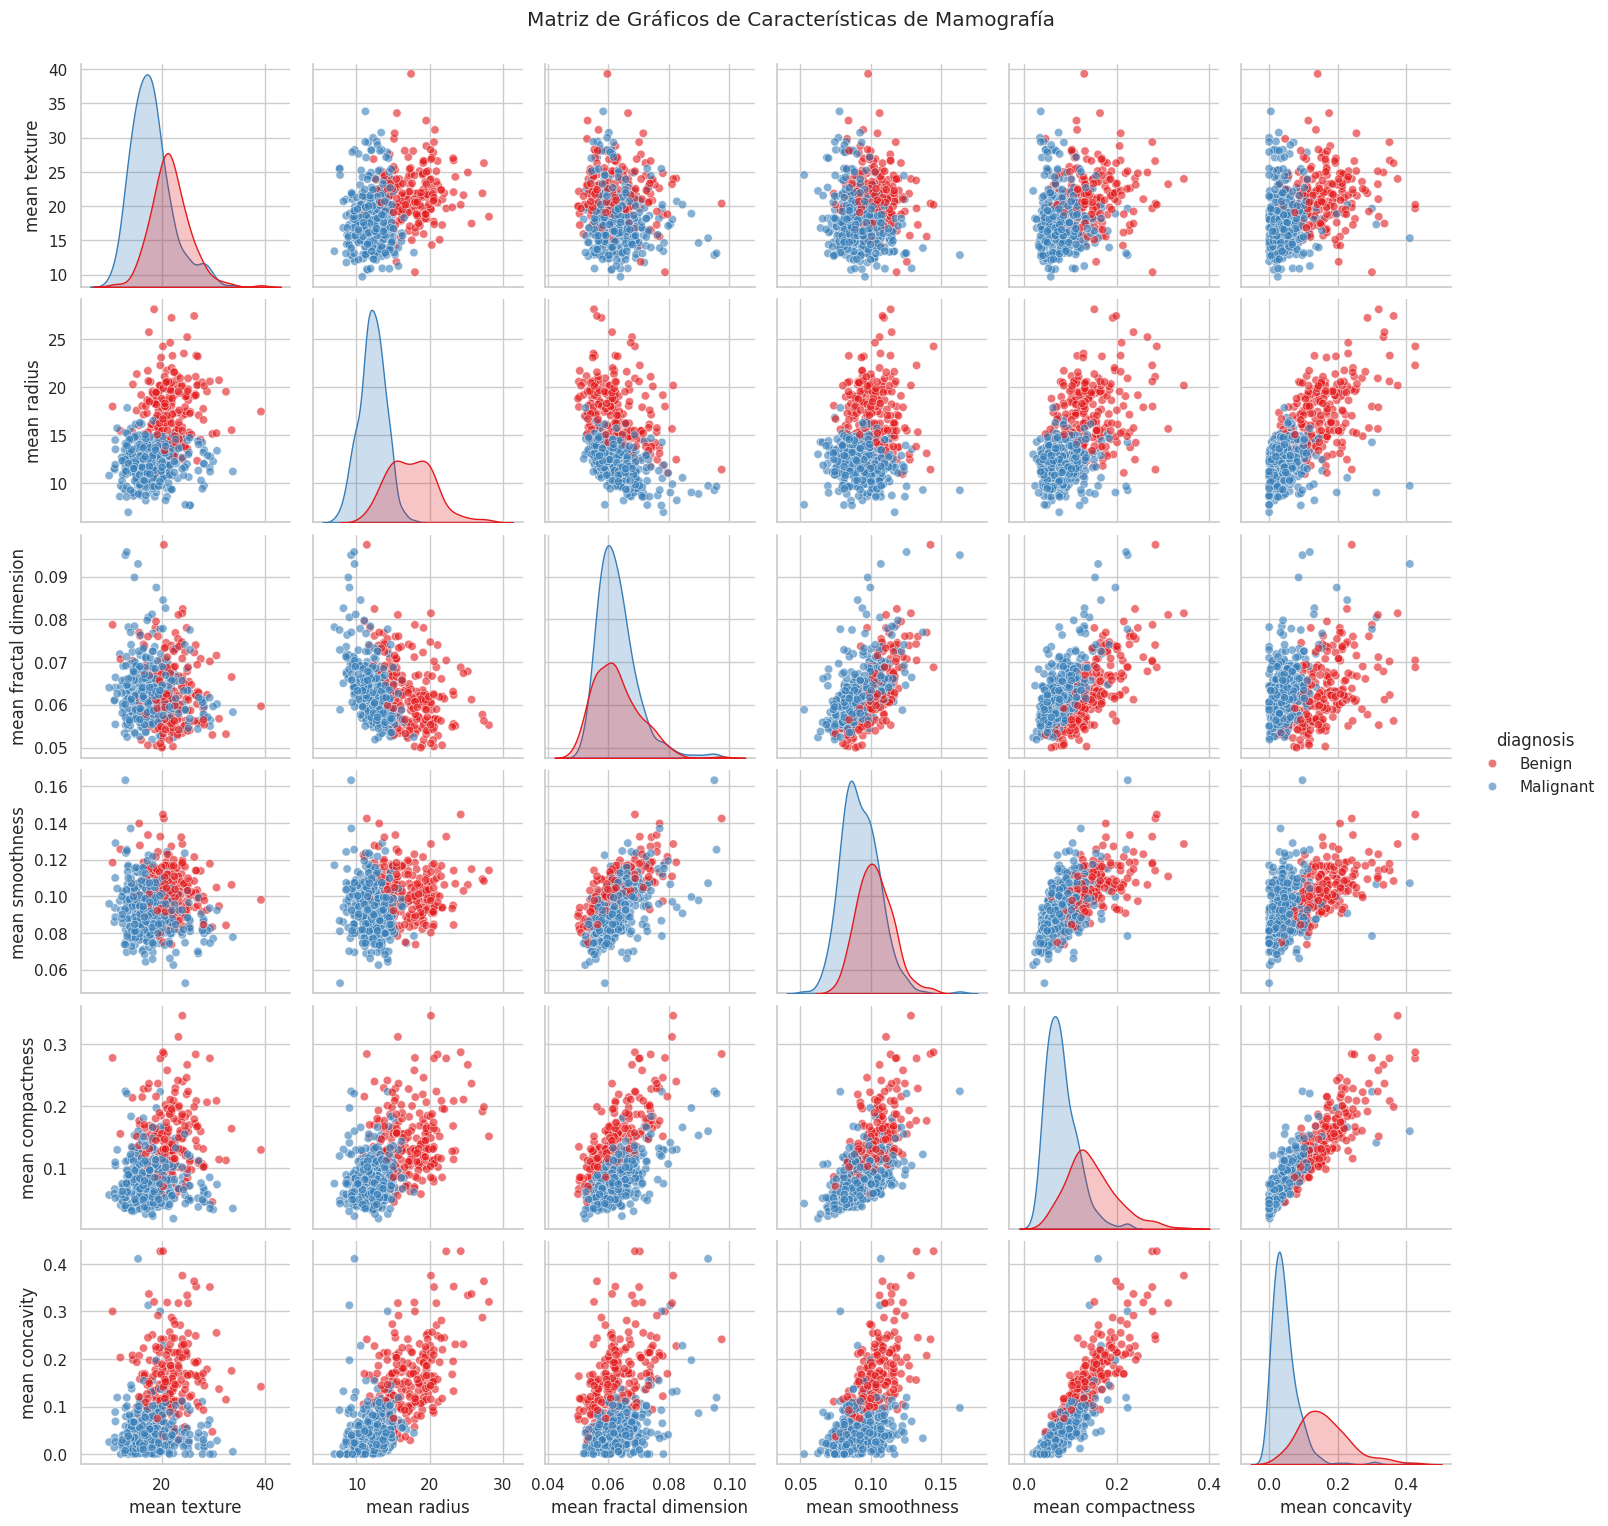

In [7]:
#GRAFICOS
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar el dataset
df_original = pd.read_csv('Mamography_data.csv')

# 2. Seleccionar variables y renombrar Label a diagnosis
columnas_interes = [
    'mean texture',
    'mean radius',
    'mean fractal dimension',
    'mean smoothness',
    'mean compactness',
    'mean concavity',
    'Label'
]
df = df_original[columnas_interes].copy()
df = df.rename(columns={'Label': 'diagnosis'})

# 3. Configurar el estilo visual
sns.set_theme(style="whitegrid")

# 4. Generar el Pairplot
# hue='diagnosis' permite ver la diferencia entre Benign y Malignant por colores
g = sns.pairplot(df, hue='diagnosis', palette='Set1', diag_kind='kde', plot_kws={'alpha': 0.6})

# 5. Ajustar el título
g.fig.suptitle("Matriz de Gráficos de Características de Mamografía", y=1.02)

# Mostrar el gráfico
plt.show()

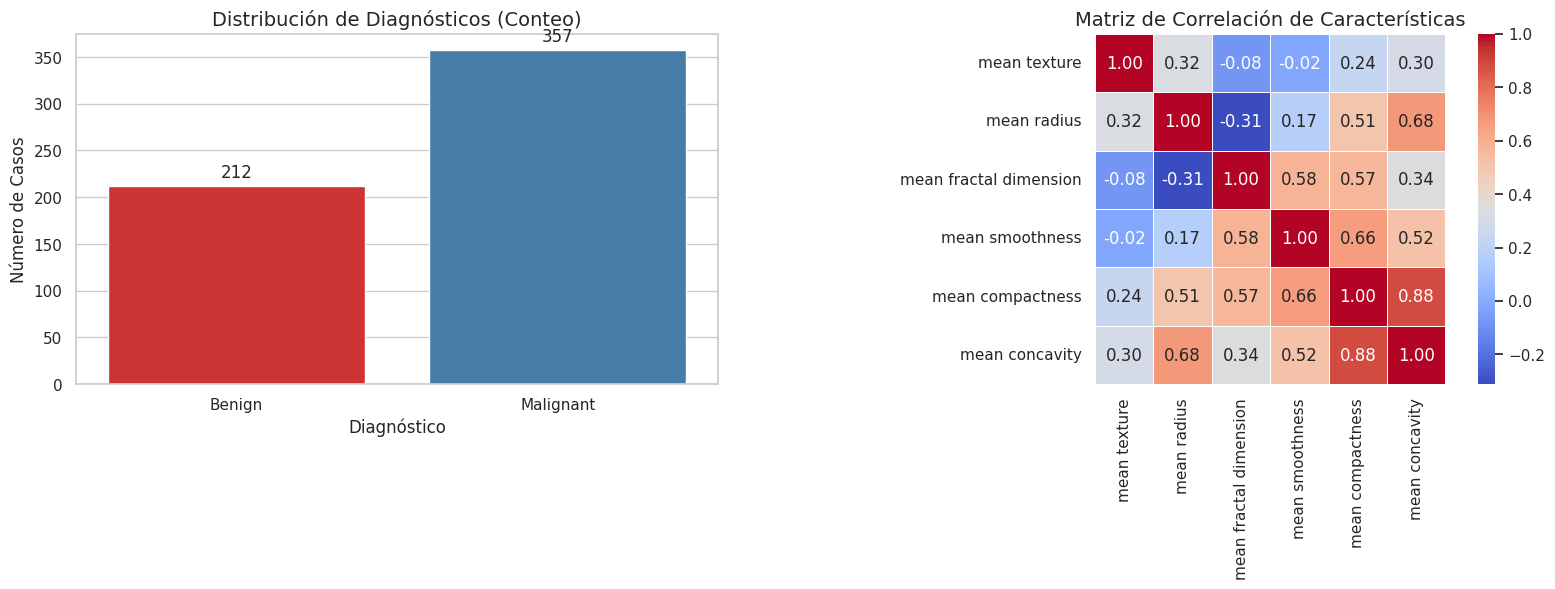

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar y preparar los datos (mismo proceso anterior)
df_original = pd.read_csv('Mamography_data.csv')
columnas_interes = [
    'mean texture', 'mean radius', 'mean fractal dimension',
    'mean smoothness', 'mean compactness', 'mean concavity', 'Label'
]
df = df_original[columnas_interes].copy()
df = df.rename(columns={'Label': 'diagnosis'})

# 2. Configurar el lienzo (2 subplots: uno para conteo y otro para heatmap)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: CONTEO DE CASOS ---
sns.countplot(x='diagnosis', data=df, ax=ax[0], palette='Set1', hue='diagnosis', legend=False)
ax[0].set_title('Distribución de Diagnósticos (Conteo)', fontsize=14)
ax[0].set_xlabel('Diagnóstico', fontsize=12)
ax[0].set_ylabel('Número de Casos', fontsize=12)

# Añadir etiquetas de valor sobre las barras
for p in ax[0].patches:
    ax[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=12)

# --- GRÁFICO 2: HEATMAP DE CORRELACIÓN ---
# Calculamos la correlación solo de las variables numéricas
corr = df.drop('diagnosis', axis=1).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=ax[1], square=True, linewidths=.5)
ax[1].set_title('Matriz de Correlación de Características', fontsize=14)

# Ajustar diseño
plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
import numpy as np
from scipy import stats # Importar el módulo stats

#DISTRIBUCION Y ESTADISTICA

# 1. Cargar y preparar el dataset (asegurarse de que df_original esté disponible)
df_original = pd.read_csv('Mamography_data.csv')
variables = [
    'mean texture', 'mean radius', 'mean fractal dimension',
    'mean smoothness', 'mean compactness', 'mean concavity'
]

# Selección y renombramiento
df = df_original[variables + ['Label']].copy()
df = df.rename(columns={'Label': 'diagnosis'})

# 2. Lista para almacenar la fusión de resultados
resumen_estadistico = []

for var in variables:
    # Separar grupos
    g_benigno = df[df['diagnosis'] == 'Benign'][var]
    g_maligno = df[df['diagnosis'] == 'Malignant'][var]

    # --- PRUEBAS DE NORMALIDAD (SHAPIRO-WILK) ---
    stat_b, p_norm_b = stats.shapiro(g_benigno)
    stat_m, p_norm_m = stats.shapiro(g_maligno)

    # Determinar si ambos son normales
    ambos_normales = (p_norm_b > 0.05) and (p_norm_m > 0.05)
    distribucion = "Normal" if ambos_normales else "No Normal"

    # --- PRUEBAS DE INFERENCIA (COMPARACIÓN) ---
    if ambos_normales:
        test_nombre = "t-test (Indep)"
        # Usamos Welch's t-test (equal_var=False) por seguridad biológica
        stat_test, p_valor_test = stats.ttest_ind(g_benigno, g_maligno, equal_var=False)
    else:
        test_nombre = "Mann-Whitney U"
        stat_test, p_valor_test = stats.mannwhitneyu(g_benigno, g_maligno)

    # --- CONSOLIDACIÓN DE RESULTADOS ---
    resumen_estadistico.append({
        'Variable': var,
        'p-Shapiro (Ben)': round(p_norm_b, 4),
        'p-Shapiro (Mal)': round(p_norm_m, 4),
        'Distribución': distribucion,
        'Test Aplicado': test_nombre,
        'p-valor (Inferencia)': f"{p_valor_test:.5e}", # Notación científica para valores muy bajos
        'Significativo (α=0.05)': "SÍ" if p_valor_test < 0.05 else "NO"
    })

# 3. Crear DataFrame final y mostrar
df_resultados = pd.DataFrame(resumen_estadistico)

print("="*100)
print("ANÁLISIS BIOESTADÍSTICO INTEGRADO: NORMALIDAD Y COMPARACIÓN DE GRUPOS")
print("="*100)
print(df_resultados.to_string(index=False))
print("="*100)


ANÁLISIS BIOESTADÍSTICO INTEGRADO: NORMALIDAD Y COMPARACIÓN DE GRUPOS
              Variable  p-Shapiro (Ben)  p-Shapiro (Mal) Distribución  Test Aplicado p-valor (Inferencia) Significativo (α=0.05)
          mean texture           0.0001            0.000    No Normal Mann-Whitney U          3.42863e-28                     SÍ
           mean radius           0.0019            0.668    No Normal Mann-Whitney U          2.69294e-68                     SÍ
mean fractal dimension           0.0000            0.000    No Normal Mann-Whitney U          5.37186e-01                     NO
       mean smoothness           0.0215            0.000    No Normal Mann-Whitney U          7.79301e-19                     SÍ
      mean compactness           0.0000            0.000    No Normal Mann-Whitney U          8.95199e-48                     SÍ
        mean concavity           0.0000            0.000    No Normal Mann-Whitney U          2.16455e-68                     SÍ


In [10]:


# 1. Cargar y preparar el dataset
df_original = pd.read_csv('Mamography_data.csv')
variables = [
    'mean texture', 'mean radius', 'mean fractal dimension',
    'mean smoothness', 'mean compactness', 'mean concavity'
]

# Selección y renombramiento (L de Label a diagnosis)
df = df_original[variables + ['Label']].copy()
df = df.rename(columns={'Label': 'diagnosis'})

# 2. Lista para almacenar los resultados comparativos
resultados_comparativos = []

for var in variables:
    # Separar grupos
    g_benigno = df[df['diagnosis'] == 'Benign'][var]
    g_maligno = df[df['diagnosis'] == 'Malignant'][var]

    # Calcular promedios
    mean_b = g_benigno.mean()
    mean_m = g_maligno.mean()

    # Identificar grupo con mayor valor
    mayor_grupo = "Maligno" if mean_m > mean_b else "Benigno"

    # --- LÓGICA ESTADÍSTICA (NORMALIDAD -> TEST) ---
    p_norm_b = stats.shapiro(g_benigno)[1]
    p_norm_m = stats.shapiro(g_maligno)[1]

    if p_norm_b > 0.05 and p_norm_m > 0.05:
        # Paramétrico
        p_valor = stats.ttest_ind(g_benigno, g_maligno, equal_var=False)[1]
        test_usado = "t-test"
    else:
        # No paramétrico
        p_valor = stats.mannwhitneyu(g_benigno, g_maligno)[1]
        test_usado = "Mann-Whitney"

    # --- CONSOLIDACIÓN ---
    resultados_comparativos.append({
        'Variable': var,
        'Promedio Benigno': round(mean_b, 4),
        'Promedio Maligno': round(mean_m, 4),
        '¿Cuál es mayor?': mayor_grupo,
        'p-valor': f"{p_valor:.4e}",
        '¿Es Significativa?': "SÍ" if p_valor < 0.05 else "NO"
    })

# 3. Crear DataFrame y mostrar resultados
df_final = pd.DataFrame(resultados_comparativos)

print("="*100)
print("ANÁLISIS DE DIFERENCIAS ENTRE GRUPOS (BENIGNO VS MALIGNO)")
print("="*100)
print(df_final.to_string(index=False))
print("="*100)

ANÁLISIS DE DIFERENCIAS ENTRE GRUPOS (BENIGNO VS MALIGNO)
              Variable  Promedio Benigno  Promedio Maligno ¿Cuál es mayor?    p-valor ¿Es Significativa?
          mean texture           21.6049           17.9148         Benigno 3.4286e-28                 SÍ
           mean radius           17.4628           12.1465         Benigno 2.6929e-68                 SÍ
mean fractal dimension            0.0627            0.0629         Maligno 5.3719e-01                 NO
       mean smoothness            0.1029            0.0925         Benigno 7.7930e-19                 SÍ
      mean compactness            0.1452            0.0801         Benigno 8.9520e-48                 SÍ
        mean concavity            0.1608            0.0461         Benigno 2.1645e-68                 SÍ


5. Para cada variable, responde:


*   ¿Cuál grupo tiene mayor valor promedio?
*   ¿Es significativa la diferencia?


Al comparar los valores promedio entre tumores benignos y malignos, se observa que **mean texture, mean radius, mean smoothness, mean compactness y mean concavity** presentan promedios **mayores en el grupo benigno**, con diferencias estadísticamente significativas (p < 0.05). En contraste, mean fractal dimension muestra un promedio levemente superior en el grupo maligno; sin embargo, esta diferencia no es estadísticamente significativa (p > 0.05), por lo que no se puede concluir que esta variable discrimine entre ambos grupos.

Cabe destacar que estos resultados no se condicen con lo esperado según la práctica clínica, donde valores más altos de textura, radio, suavidad y concavidad suelen asociarse a malignidad. En un contexto aplicado, sería recomendable revisar la base de datos para descartar posibles errores en el registro, codificación de variables o etiquetado de los grupos.



---

### Parte 2: Modelamiento Predictivo

1. Codifica la variable `diagnosis` como 0 = Benigno y 1 = Maligno.
2. Usa las siguientes variables como predictores:
   - `mean texture`
   - `mean radius`
   - `mean fractal dimension`
   - `mean smoothness`
   - `mean compactness`
   - `mean concavity`
3. Normaliza las variables predictoras usando `StandardScaler`.
4. Ajusta un modelo de regresión logística con `statsmodels` y analiza el resumen.
5. Interpreta:
   - ¿Cuáles variables tienen mayor efecto sobre la probabilidad de malignidad?
   - Calcula e interpreta los **odds ratios** (`np.exp()`).
6. Usa el modelo para predecir la probabilidad de malignidad de tres nuevos pacientes:

| Paciente | mean texture | mean radius | mean fractal dimension | mean smoothness | mean compactness | mean concavity |
|----------|--------------|-------------|------------------------|------------------|------------------|----------------|
| A        | 17.0         | 14.0        | 0.055                  | 0.095            | 0.120            | 0.300          |
| B        | 23.0         | 18.0        | 0.285                  | 0.110            | 0.180            | 0.410          |
| C        | 12.0         | 10.0        | 0.040                  | 0.080            | 0.070            | 0.100          |

7. Preguntas:
   - ¿Qué paciente tiene mayor probabilidad de tener un tumor maligno?
   - ¿Cuál clasificarías como benigno con mayor seguridad?
   - ¿Cuál caso parece ambiguo?

> **Nota**: Para clasificar, puedes aplicar un umbral simple: si la probabilidad es mayor a 0.5, se predice como maligno; si es menor o igual a 0.5, se predice como benigno.


In [11]:
# <CODE> Librerías
import statsmodels.api as sm
from scipy.stats import shapiro, mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [12]:
# <CODE> Parte 2.
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# 1. Cargar y preparar el dataset
df_original = pd.read_csv('Mamography_data.csv')
variables = [
    'mean texture', 'mean radius', 'mean fractal dimension',
    'mean smoothness', 'mean compactness', 'mean concavity'
]

# Selección y codificación: 0 = Benigno, 1 = Maligno
df = df_original[variables + ['Label']].copy()
df['diagnosis'] = df['Label'].map({'Benign': 0, 'Malignant': 1})

# 2. Normalización de variables predictoras
scaler = StandardScaler()
X = df[variables]
X_scaled = scaler.fit_transform(X)

# Convertir de nuevo a DataFrame para mantener nombres de columnas y añadir constante
X_scaled_df = pd.DataFrame(X_scaled, columns=variables)
X_scaled_df = sm.add_constant(X_scaled_df)  # Intercepto obligatorio en Logit
y = df['diagnosis']

# 3. Ajuste del Modelo de Regresión Logística
modelo = sm.Logit(y, X_scaled_df).fit()
print(modelo.summary())

# 4. Cálculo de Odds Ratios e Interpretación
odds_ratios = np.exp(modelo.params)
print("\n--- ODDS RATIOS (Interpretación del efecto) ---")
print(odds_ratios)

# 5. Predicción para nuevos pacientes
pacientes_nuevos = pd.DataFrame([
    [17.0, 14.0, 0.055, 0.095, 0.120, 0.300], # Paciente A
    [23.0, 18.0, 0.285, 0.110, 0.180, 0.410], # Paciente B
    [12.0, 10.0, 0.040, 0.080, 0.070, 0.100]  # Paciente C
], columns=variables)

#Escalar los datos de los nuevos pacientes con el MISMO scaler
pacientes_scaled = scaler.transform(pacientes_nuevos)
pacientes_scaled_df = pd.DataFrame(pacientes_scaled, columns=variables)
pacientes_scaled_df = sm.add_constant(pacientes_scaled_df, has_constant='add')

# Realizar predicción de probabilidad
probabilidades = modelo.predict(pacientes_scaled_df)

print("\n--- PREDICCIONES PARA NUEVOS PACIENTES ---")
for i, paciente in enumerate(['A', 'B', 'C']):
    print(f"Paciente {paciente}: Probabilidad de Malignidad = {probabilidades[i]:.2%}")


Optimization terminated successfully.
         Current function value: 0.139310
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:              diagnosis   No. Observations:                  569
Model:                          Logit   Df Residuals:                      562
Method:                           MLE   Df Model:                            6
Date:                Fri, 16 Jan 2026   Pseudo R-squ.:                  0.7890
Time:                        14:09:10   Log-Likelihood:                -79.267
converged:                       True   LL-Null:                       -375.72
Covariance Type:            nonrobust   LLR p-value:                7.908e-125
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0.8028      0.219      3.670      0.000       0.374      

7 Preguntas:

*   ¿Qué paciente tiene mayor probabilidad de tener un tumor maligno?

  El paciente C, casi de 100%

*   ¿Cuál clasificarías como benigno con mayor seguridad?

  El paciente A

*   ¿Cuál caso parece ambiguo?

  El paciente B, valor muy cercano al umbral establecido de 0.5

---

### 🧮 Parte 3: Análisis de Componentes Principales (PCA)

1. Aplica PCA y normalize utilizando las 6 variables mencionadas.
2. Reduce la dimensionalidad a 5 y grafica los dos primeros componentes principales.
   - Grafico 1: Scatter plot sin colorear segun la variable objetivo.
   - Grafico 2: Scatter plot coloreando los puntos según la variable `diagnosis
   - Grafica la varianza explicada por cada componente.
   - Biplot de los dos primeros componentes principales, coloreando por la variable `diagnosis`.
3. Observa:
   - ¿Los grupos se separan en el espacio de componentes principales?
   - ¿Cuánta varianza explican los primeros 2 componentes?
   - ¿Qué variables tienen mayor peso en cada componente?
4. ¿Podrías usar PCA como paso previo a la regresión? ¿Por qué sí o no?

In [13]:
# <CODE> Librerías
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA # Importamos PCA
from sklearn.datasets import load_breast_cancer
import os

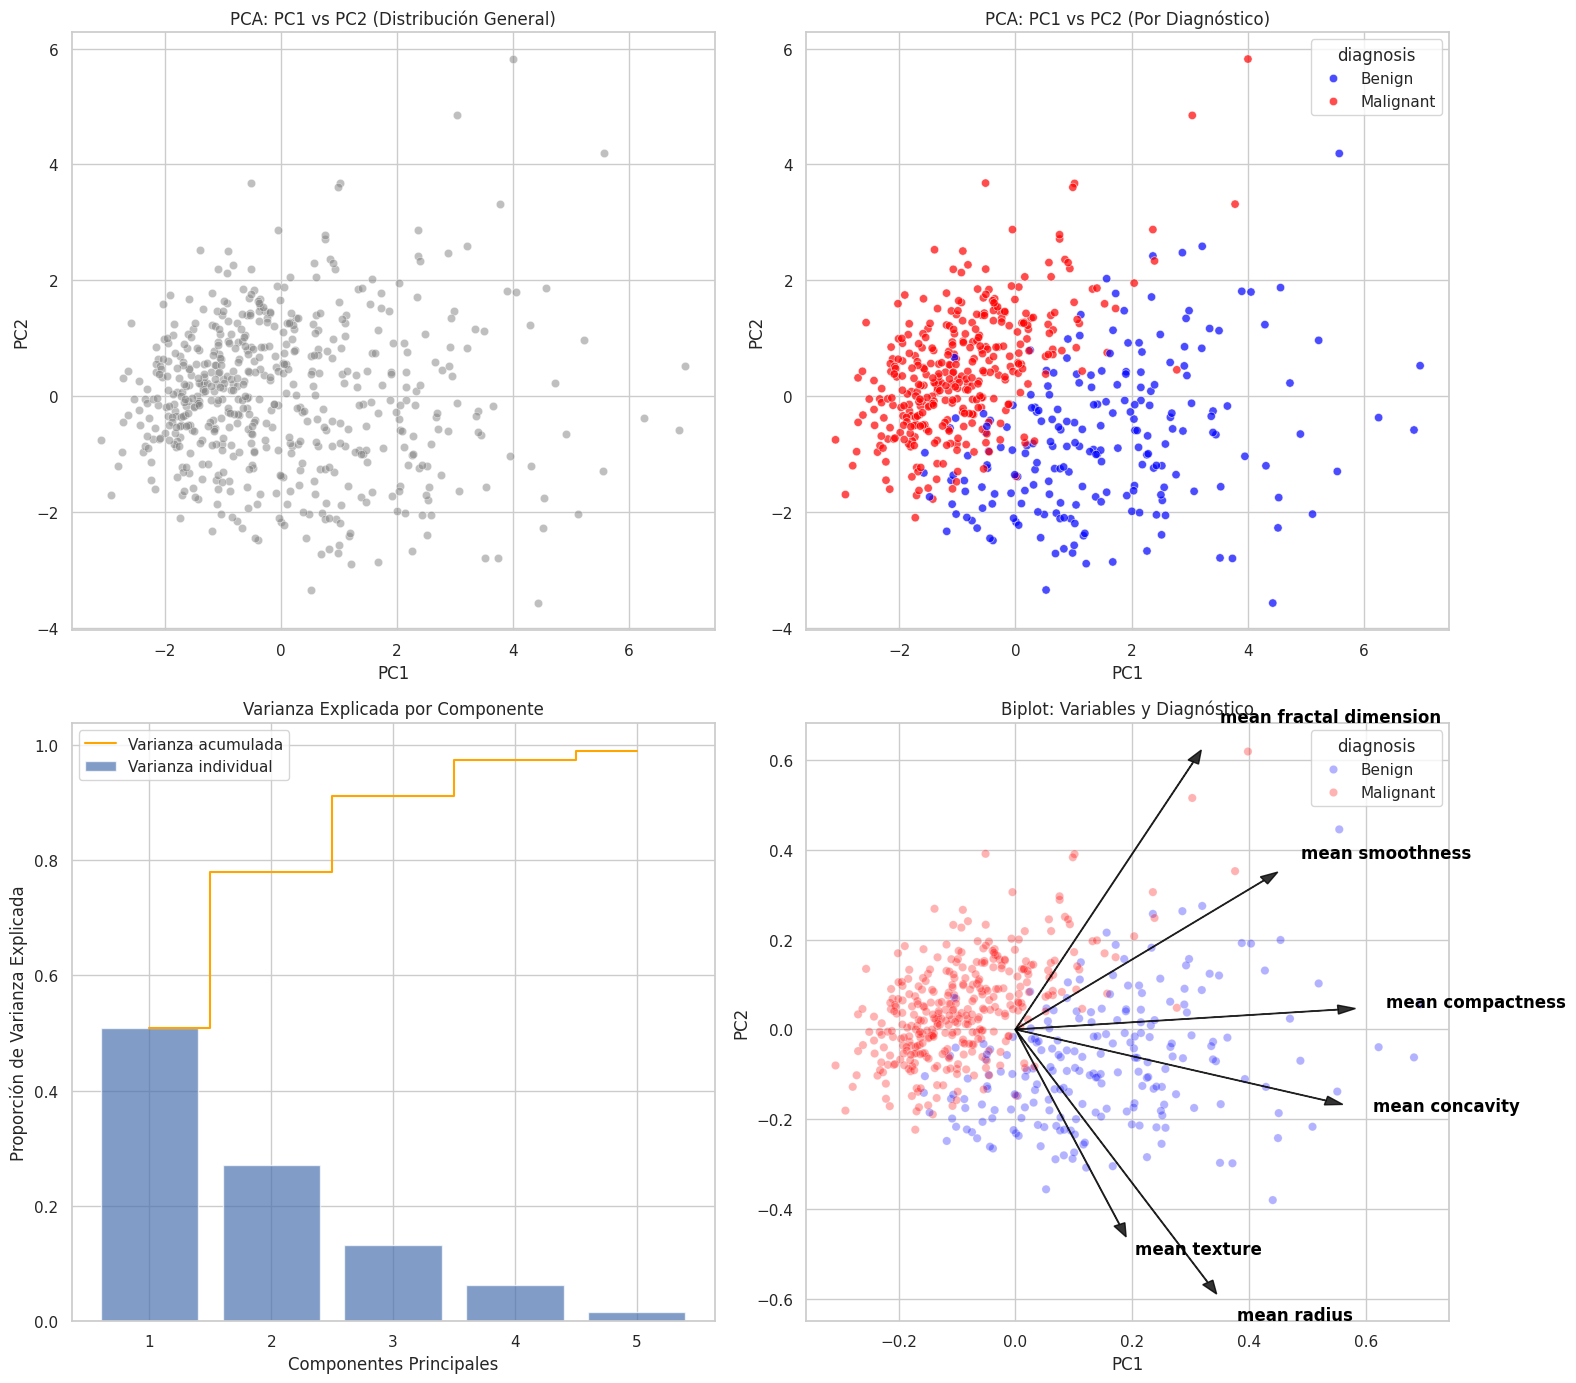

In [14]:
# <CODE> Parte 3

# 1. Cargar y preparar los datos
df = pd.read_csv('Mamography_data.csv')
variables = ['mean texture', 'mean radius', 'mean fractal dimension',
             'mean smoothness', 'mean compactness', 'mean concavity']

# Renombrar variable objetivo
df = df.rename(columns={'Label': 'diagnosis'})

# 2. Normalización (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[variables])

# 3. Aplicar PCA (Reducción a 5 componentes)
pca = PCA(n_components=5)
pca_result = pca.fit_transform(X_scaled)

# Crear un nuevo DataFrame con los componentes
df_pca = pd.DataFrame(data=pca_result, columns=[f'PC{i+1}' for i in range(5)])
df_pca['diagnosis'] = df['diagnosis'].values

# --- GENERACIÓN DE GRÁFICOS ---
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
scale = 3
# Gráfico 1: Scatter plot sin colorear (PC1 vs PC2)
sns.scatterplot(data=df_pca, x='PC1', y='PC2', color='gray', alpha=0.5, ax=axes[0,0])
axes[0,0].set_title('PCA: PC1 vs PC2 (Distribución General)')

# Gráfico 2: Scatter plot coloreado por diagnosis (Azul/Rojo)
colors = {"Benign": "blue", "Malignant": "red"}
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='diagnosis', palette=colors, alpha=0.7, ax=axes[0,1])
axes[0,1].set_title('PCA: PC1 vs PC2 (Por Diagnóstico)')

# Gráfico 3: Varianza explicada
exp_var = pca.explained_variance_ratio_
axes[1,0].bar(range(1, 6), exp_var, alpha=0.7, label='Varianza individual')
axes[1,0].step(range(1, 6), np.cumsum(exp_var), where='mid', label='Varianza acumulada', color='orange')
axes[1,0].set_ylabel('Proporción de Varianza Explicada')
axes[1,0].set_xlabel('Componentes Principales')
axes[1,0].set_title('Varianza Explicada por Componente')
axes[1,0].legend()

# Gráfico 4: Biplot (Función personalizada para ver vectores de carga)
def draw_biplot(score, coeff, labels, groups, ax):
    xs = score[:, 0]
    ys = score[:, 1]
    n = coeff.shape[0]
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())

    sns.scatterplot(x=xs * scalex, y=ys * scaley, hue=groups, palette=colors, alpha=0.3, ax=ax)

    for i in range(n):
        ax.arrow(0, 0, coeff[i,0], coeff[i,1], color='black', alpha=0.8, head_width=0.02)
        ax.text(coeff[i,0]*1.15, coeff[i,1]*1.15, labels[i], color='black', fontweight='bold')

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title("Biplot: Variables y Diagnóstico")

draw_biplot(pca_result, np.transpose(pca.components_[0:2, :]), variables, df_pca['diagnosis'], axes[1,1])

plt.tight_layout()
plt.show()

In [15]:
# --- CÓDIGO PARA EXTRAER VARIANZA Y PESOS ---
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Preparación (Asegúrate de tener el df con las 6 variables)
variables = ['mean texture', 'mean radius', 'mean fractal dimension',
             'mean smoothness', 'mean compactness', 'mean concavity']
X_scaled = StandardScaler().fit_transform(df[variables])

# 2. Ejecutar PCA
pca = PCA(n_components=5)
pca.fit(X_scaled)

# 3. Extraer resultados
varianza_individual = pca.explained_variance_ratio_
varianza_acumulada_2 = varianza_individual[0] + varianza_individual[1]
pesos = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(5)], index=variables)

# --- RESULTADOS ---
print(f"Varianza explicada por PC1 y PC2 juntos: {varianza_acumulada_2:.2%}")
print("\nVarianza individual por componente:")
for i, v in enumerate(varianza_individual):
    print(f" PC{i+1}: {v:.2%}")

print("\nVariables con mayor peso (loadings) en cada componente:")
for pc in ['PC1', 'PC2']:
    # Obtenemos la variable con el valor absoluto más alto en ese componente
    top_var = pesos[pc].abs().idxmax()
    peso_val = pesos.loc[top_var, pc]
    print(f" En {pc}, la variable con mayor impacto es '{top_var}' (Peso: {peso_val:.3f})")

Varianza explicada por PC1 y PC2 juntos: 77.96%

Varianza individual por componente:
 PC1: 50.81%
 PC2: 27.15%
 PC3: 13.15%
 PC4: 6.24%
 PC5: 1.52%

Variables con mayor peso (loadings) en cada componente:
 En PC1, la variable con mayor impacto es 'mean compactness' (Peso: 0.552)
 En PC2, la variable con mayor impacto es 'mean fractal dimension' (Peso: 0.596)


***¿Los grupos se separan en el espacio de componentes principales?***
En el espacio definido por las dos primeras componentes principales se observa una separación parcial entre los grupos benigno y maligno, con una zona de superposición, por lo que no existe una discriminación completa entre ambos grupos.

***¿Cuánta varianza explican los primeros 2 componentes?***
Las dos primeras componentes principales explican conjuntamente el 77,96% de la variabilidad total, por lo que una representación bidimensional resulta adecuada para resumir la información del conjunto de datos sin perder una cantidad relevante de información.

***¿Qué variables tienen mayor peso en cada componente?***
La PC1 explica el 50,81% de la varianza y está dominada principalmente por mean compactness, lo que indica que esta variable es la que más contribuye a la variabilidad global. Por su parte, la PC2 explica el 27,15% de la varianza y está influenciada principalmente por mean fractal dimension, aportando información adicional e independiente de la primera componente. El aporte de las componentes restantes es menor.

***¿Podrías usar PCA como paso previo a la regresión? ¿Por qué sí o no?***
El PCA podría utilizarse como paso previo a una regresión logística con el objetivo de reducir la correlación entre variables y simplificar el modelo. Sin embargo, en este caso el número de variables es reducido y estas permiten una interpretación clínica directa, la cual se pierde al trabajar con componentes principales. Además, dado que algunas asociaciones observadas en el PCA no se condicen completamente con lo esperado desde la práctica clínica, en un contexto aplicado sería recomendable priorizar el uso de las variables originales y revisar la calidad de la base de datos antes de optar por una reducción de dimensionalidad. Por ello, el uso de PCA dependerá de si se prioriza la simplificación del modelo o la interpretabilidad clínica.
